# 1-Data-Preprocessing

## load data

In [5]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv('/Users/Safa/code/Reenad-Alzahrani/Medical_Insurance_Cost_Prediction/raw_data/medical_insurance.csv')
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## clean data

#### cheak for duplication

In [12]:
len(df)

100000

In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[df.duplicated()]

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure


##### the data is clean and not duplicated

#### Cheak columns with unreasonable or incorrect values

In [24]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,99835.000000,99835.000000,9.983500e+04,99835.000000,99835.000000,99835.000000,99835.000000,99835.000000,99835.000000,99835.000000,...,99835.000000,99835.000000,99835.000000,99835.000000,99835.000000,99835.000000,99835.000000,99835.000000,99835.000000,99835.000000
mean,50008.217849,47.600040,4.987054e+04,2.430911,0.898493,26.989678,1.927611,0.093655,0.373536,1.236260,...,0.014764,0.108399,0.130135,0.508709,0.158782,0.508499,0.509390,0.509240,0.368398,0.169780
std,28869.264298,15.884714,4.679521e+04,1.075184,0.950723,4.995274,1.737801,0.304824,1.373365,1.209194,...,0.120609,0.310885,0.336453,0.749870,0.463731,0.747236,0.753633,0.750491,0.482372,0.375441
min,1.000000,1.000000,1.100000e+03,1.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.500000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50012.000000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,75010.500000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.000000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.000000,7.000000,1.000000,1.000000


In [26]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

sex: ['Female' 'Male' 'Other']
region: ['North' 'Central' 'West' 'South' 'East']
urban_rural: ['Suburban' 'Urban' 'Rural']
education: ['Doctorate' 'No HS' 'HS' 'Some College' 'Masters' 'Bachelors']
marital_status: ['Married' 'Single' 'Divorced' 'Widowed']
employment_status: ['Retired' 'Employed' 'Self-employed' 'Unemployed']
smoker: ['Never' 'Current' 'Former']
alcohol_freq: [nan 'Weekly' 'Daily' 'Occasional']
plan_type: ['PPO' 'POS' 'HMO' 'EPO']
network_tier: ['Bronze' 'Gold' 'Platinum' 'Silver']


##### the data is clean 

### cheak for outliers

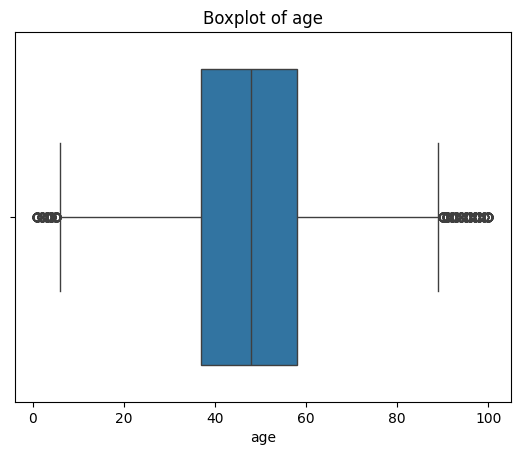

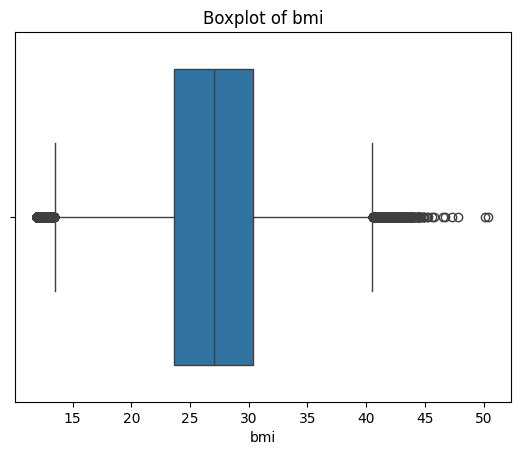

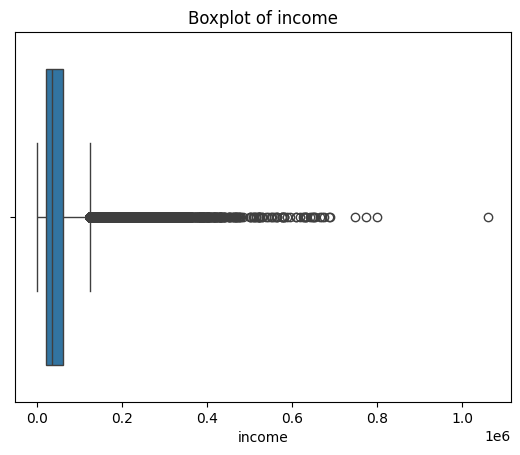

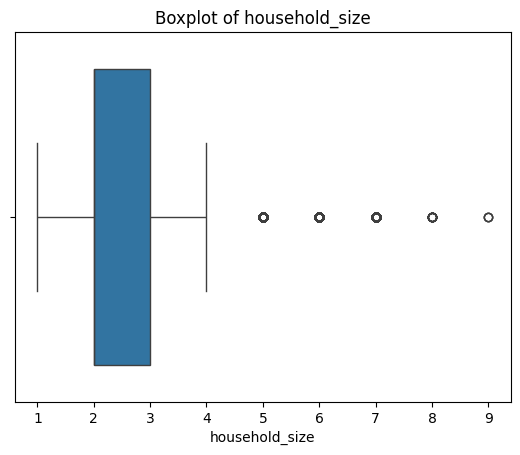

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['age', 'bmi', 'income', 'household_size']

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [30]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['income'] < lower) | (df['income'] > upper)]

print("outliers:", outliers.shape[0])

outliers: 6226
